# Super Market Data Analytics

**Student:** ChandhraShekhar  
**Program:** IBM SkillsBuild Data Analytics with AI Academic Internship Program  

This notebook follows **DATA → INFORMATION → INSIGHT → DECISION → ACTION** using the supplied supermarket table.

## 1. Load and inspect the supplied dataset
The PDF table was extracted into `dataset/supermarket_data.csv`. The original PDF is preserved outside the submission folder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

DATA_PATH = Path('dataset/supermarket_data.csv')
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
df.info()

Shape: (500, 13)


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4.0,57.13,UPI,3.8,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9.0,66.85,Net Banking,3.9,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3.0,57.28,Card,3.4,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2.0,168.27,Card,4.5,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5.0,130.57,Cash,3.1,652.85


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice ID     500 non-null    str    
 1   Date           500 non-null    str    
 2   Branch         500 non-null    str    
 3   City           500 non-null    str    
 4   Customer Type  500 non-null    str    
 5   Gender         500 non-null    str    
 6   Product        500 non-null    str    
 7   Category       500 non-null    str    
 8   Quantity       500 non-null    float64
 9   Unit Price     500 non-null    float64
 10  Payment        500 non-null    str    
 11  Rating         500 non-null    float64
 12  Sales          500 non-null    float64
dtypes: float64(4), str(9)
memory usage: 77.9 KB


## 2. Data quality analysis and cleaning
The source table is checked for missing values, duplicates, invalid dates, impossible numerical values, and Sales formula consistency. Valid records are retained; invalid records would be excluded from the cleaned analysis dataframe rather than silently changed.

In [2]:
quality = pd.DataFrame({'Missing values': df.isna().sum(), 'Unique values': df.nunique()})
display(quality)
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate invoice IDs:', df['Invoice ID'].duplicated().sum())
print('Date range:', df['Date'].min(), 'to', df['Date'].max())
print('Invalid ratings:', ((pd.to_numeric(df['Rating'], errors='coerce') < 0) | (pd.to_numeric(df['Rating'], errors='coerce') > 5)).sum())
formula_difference = (df['Sales'] - df['Quantity'] * df['Unit Price']).round(2)
print('Sales formula mismatches beyond 0.01:', (formula_difference.abs() > 0.01).sum())
clean = df.copy()
clean['Date'] = pd.to_datetime(clean['Date'], errors='coerce')
clean = clean.dropna(subset=['Date']).copy()
clean = clean[(clean['Quantity'] > 0) & (clean['Unit Price'] > 0) & clean['Rating'].between(0,5) & (clean['Sales'] > 0)].copy()
clean['Year'] = clean['Date'].dt.year
clean['Month'] = clean['Date'].dt.month
clean['Month Name'] = clean['Date'].dt.strftime('%b')
clean['Day'] = clean['Date'].dt.day
clean['Day of Week'] = clean['Date'].dt.day_name()
print('Clean rows:', len(clean))

,Missing values,Unique values
Invoice ID,0,500
Date,0,173
Branch,0,4
City,0,4
Customer Type,0,2
Gender,0,2
Product,0,20
Category,0,8
Quantity,0,10
Unit Price,0,488


Duplicate rows: 0
Duplicate invoice IDs: 0
Date range: 2026-01-01 to 2026-07-01
Invalid ratings: 0
Sales formula mismatches beyond 0.01: 0
Clean rows: 500


## 3. KPI analysis and exploratory analysis

,Value
Total sales,244411.08000
Transactions,500.00000
Quantity sold,2768.00000
Average transaction,488.82216
Average rating,3.99440


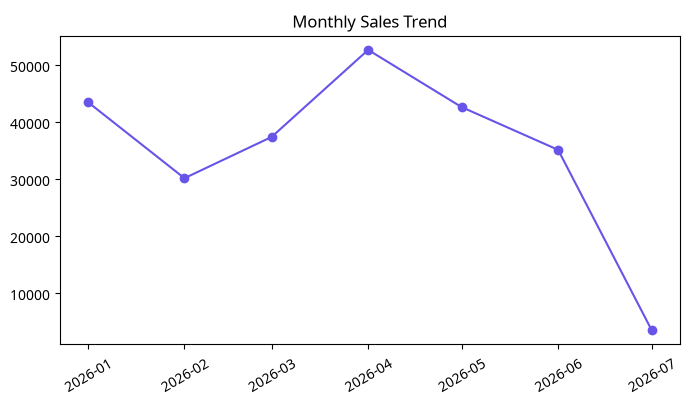

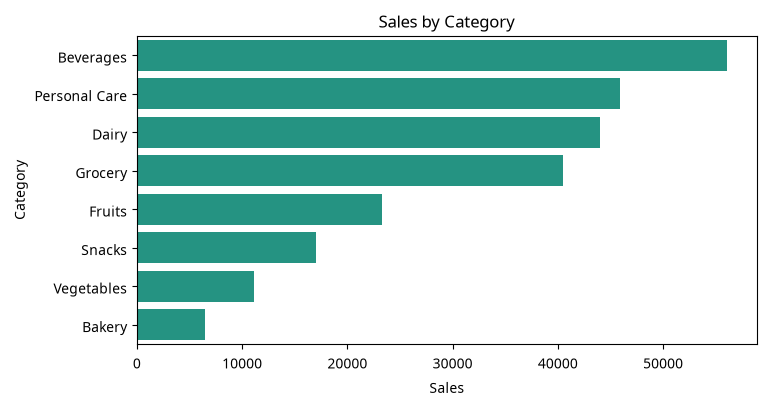

,Branch,City,Sales
2,C,Mumbai,72469.45
1,B,Delhi,64116.26
3,D,Bengaluru,55468.29
0,A,Jaipur,52357.08


In [3]:
kpis = {'Total sales': clean['Sales'].sum(), 'Transactions': clean['Invoice ID'].nunique(), 'Quantity sold': clean['Quantity'].sum(), 'Average transaction': clean['Sales'].mean(), 'Average rating': clean['Rating'].mean()}
display(pd.Series(kpis).to_frame('Value'))
monthly = clean.groupby(clean['Date'].dt.to_period('M'))['Sales'].sum().reset_index(); monthly['Date'] = monthly['Date'].dt.to_timestamp()
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(monthly['Date'], monthly['Sales'], marker='o', color='#6754e8'); ax.set_title('Monthly Sales Trend'); ax.tick_params(axis='x', rotation=30); plt.show()
category_sales = clean.groupby('Category', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)
fig, ax = plt.subplots(figsize=(8,4)); sns.barplot(data=category_sales, x='Sales', y='Category', ax=ax, color='#13a58e'); ax.set_title('Sales by Category'); plt.show()
branch_sales = clean.groupby(['Branch','City'], as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)
display(branch_sales)

## 4. Predictive analytics: Rating prediction
Sales is not used as a target because it is mathematically derived from Quantity × Unit Price. Instead, the model estimates customer Rating from transaction and context features. This is an exploratory prioritization model, not a causal claim and not a replacement for collecting actual feedback.

,Value
Baseline MAE,0.472490
Model MAE,0.492477
Model RMSE,0.573958
Model R2,-0.191530


,Feature,Importance
7,Unit Price,0.011734
2,Customer Type,0.004159
8,Payment,0.001324
3,Gender,0.001077
5,Category,0.000876
9,Month,-0.000877
4,Product,-0.001577
0,Branch,-0.006065
1,City,-0.006552
6,Quantity,-0.007715


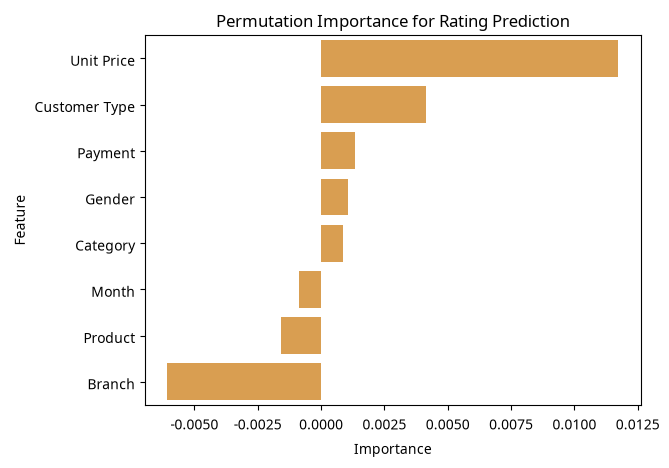

In [4]:
features = ['Branch','City','Customer Type','Gender','Product','Category','Quantity','Unit Price','Payment','Month','Day of Week']
target = 'Rating'
X, y = clean[features], clean[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cat = [c for c in features if not pd.api.types.is_numeric_dtype(X[c])]; num = [c for c in features if c not in cat]
pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat), ('num', 'passthrough', num)])
model = Pipeline([('preprocess', pre), ('model', RandomForestRegressor(n_estimators=250, max_depth=8, min_samples_leaf=2, random_state=42))])
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train); model.fit(X_train, y_train)
pred = model.predict(X_test)
model_metrics = {'Baseline MAE': mean_absolute_error(y_test, baseline.predict(X_test)), 'Model MAE': mean_absolute_error(y_test, pred), 'Model RMSE': mean_squared_error(y_test, pred) ** 0.5, 'Model R2': r2_score(y_test, pred)}
display(pd.Series(model_metrics).to_frame('Value'))
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')
importance = pd.DataFrame({'Feature': features, 'Importance': perm.importances_mean}).sort_values('Importance', ascending=False)
display(importance)
sns.barplot(data=importance.head(8), x='Importance', y='Feature', color='#f0a13a'); plt.title('Permutation Importance for Rating Prediction'); plt.show()

## 5. FACT → INSIGHT → OPPORTUNITY/RISK → ACTION

- **Fact:** The leading category and city are identified from cleaned Sales totals. **Insight:** Sales contribution is concentrated in identifiable categories and locations. **Opportunity/Risk:** Availability and execution in leading segments matter, while over-reliance creates exposure. **Action:** Monitor inventory and compare the leading city/category with lower-performing segments.
- **Fact:** Sales is deterministically related to Quantity and Unit Price. **Insight:** A Sales model would reproduce a formula rather than add intelligence. **Action:** Use the Rating model only as an exploratory signal and improve feedback capture before operationalizing prediction.

## 6. Limitations and conclusion
The PDF table is a static six-month extract. It supports descriptive analysis and an exploratory rating model, but it does not establish causation, customer lifetime value, inventory availability, or promotional uplift.